# **World Happiness Index - Part 2: Analysis**

This notebook is the second part of our World Happiness data science project. In Part 1, we conducted exploratory data analysis (EDA) and performed data cleaning to prepare the dataset. The cleaned dataset, `world_happiness_master.csv`, serves as the foundation for this phase of the project.

In this part, we aim to extract insights and address three core questions using the prepared dataset:

### Key Questions:
- **What are the main factors that influence a country's happiness score?**  
  We will identify which features contribute most significantly to happiness and explore the differences between countries with high and low scores.

- **Can we group countries based on happiness scores?**  
  By applying clustering techniques, we’ll examine whether countries form distinct groups, possibly influenced by regional or cultural similarities.

- **Can we predict future happiness scores for a given country?**  
  We'll explore time series forecasting methods to estimate happiness scores for upcoming years based on historical data.


Libraries Setup

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from statsmodels.tsa.holtwinters import Holt

import warnings
warnings.filterwarnings('ignore')

sns.set(style="whitegrid")
%matplotlib inline

print("Libraries imported successfully.")

Libraries imported successfully.


Loading Dataset

In [96]:
file_path = 'world_happiness_master.csv'

df = pd.read_csv(file_path, na_values=[''])
print(f"Dataset loaded successfully from {file_path}")

print("\n--- DataFrame Info ---")
df.info()

print("\n--- Missing Values Per Column ---")
print(df.isnull().sum())

print("\n--- First 5 Rows ---")
print(df.head())


Dataset loaded successfully from world_happiness_master.csv

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   country            782 non-null    object 
 1   happiness_rank     782 non-null    int64  
 2   happiness_score    782 non-null    float64
 3   gdp_per_capita     782 non-null    float64
 4   social_support     782 non-null    float64
 5   life_expectancy    782 non-null    float64
 6   freedom            782 non-null    float64
 7   generosity         782 non-null    float64
 8   corruption         781 non-null    float64
 9   dystopia_residual  470 non-null    float64
 10  year               782 non-null    int64  
dtypes: float64(8), int64(2), object(1)
memory usage: 67.3+ KB

--- Missing Values Per Column ---
country                0
happiness_rank         0
happiness_score        0
gdp_per_capita

## Q1: Key Factors that Influence Happiness Scores

To answer this question, we will first use a **correlation matrix** to visualize the relationships between all the features in the dataset. This will help us understand how strongly each feature is correlated with happiness scores. 

Next, we will train a **Random Forest Regressor** to identify the most important features that contribute to predicting happiness scores, highlighting the key factors that drive higher or lower scores.


#### 📊 Correlation Matrix

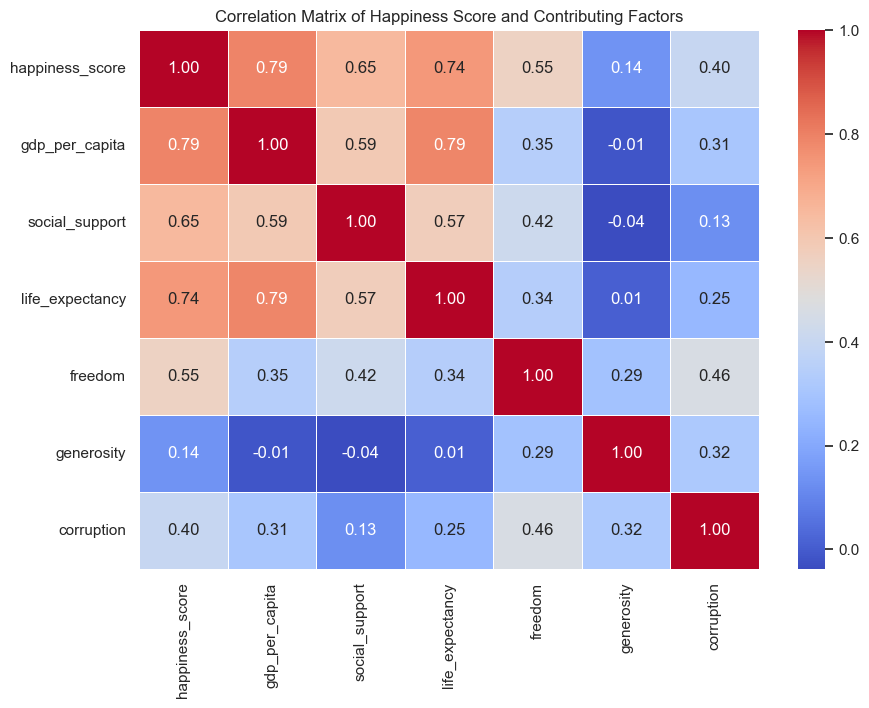


--- Correlation with Happiness Score ---
gdp_per_capita     0.789719
life_expectancy    0.742843
social_support     0.651246
freedom            0.553365
corruption         0.398418
generosity         0.138142
Name: happiness_score, dtype: float64


In [97]:
factor_cols = ['gdp_per_capita', 'social_support', 'life_expectancy',
                'freedom', 'generosity', 'corruption']
score_col = 'happiness_score'

analysis_cols = [score_col] + factor_cols

correlation_matrix = df[analysis_cols].dropna().corr()

plt.figure(figsize=(10, 7))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Happiness Score and Contributing Factors')
plt.show()

print("\n--- Correlation with Happiness Score ---")
score_correlations = correlation_matrix[score_col].drop(score_col)
print(score_correlations.sort_values(ascending=False))


#### 🌲 Random Forest Feature Importance


Random Forest OOB Score: 0.8126

--- Feature Importance (Random Forest) ---
           Feature  Importance
0   gdp_per_capita    0.497531
2  life_expectancy    0.219575
3          freedom    0.127699
1   social_support    0.061063
5       corruption    0.049951
4       generosity    0.044180


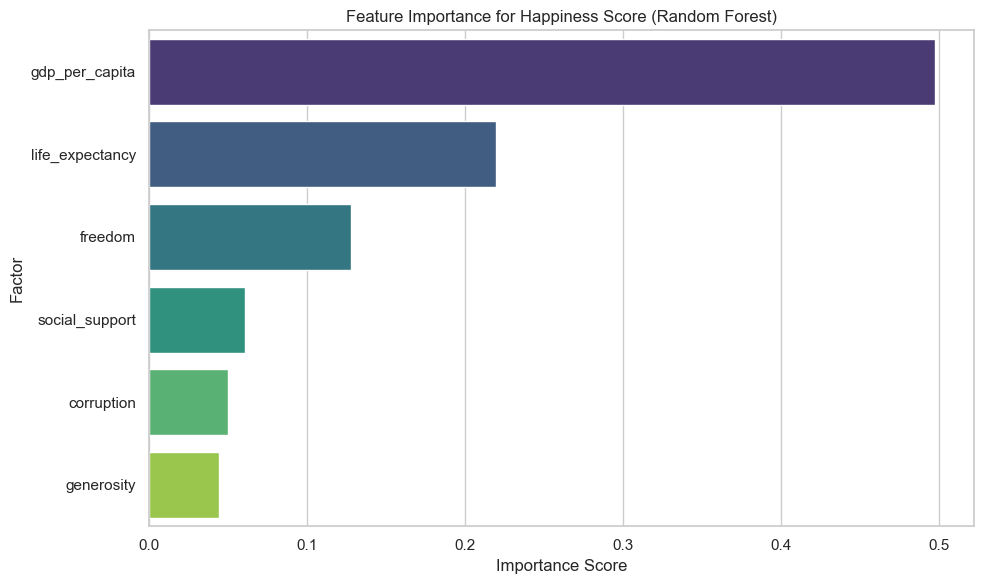

In [98]:
X = df[factor_cols].copy()
y = df[score_col].copy()

if X['corruption'].isnull().any():
    median_corruption = X['corruption'].median()
    X['corruption'] = X['corruption'].fillna(median_corruption)

valid_indices = X.notna().all(axis=1) & y.notna()
X = X[valid_indices]
y = y[valid_indices]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, oob_score=True)
rf_model.fit(X, y)

print(f"\nRandom Forest OOB Score: {rf_model.oob_score_:.4f}")  

importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

print("\n--- Feature Importance (Random Forest) ---")
print(importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', dodge=False, legend=False)
plt.title('Feature Importance for Happiness Score (Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Factor')
plt.tight_layout()
plt.show()

### Analysis Results

Based on our analysis, we observed the following results:

---

**Correlation with Happiness Score:**

The correlation matrix revealed the following relationships between the happiness score and various factors:

| Feature            | Correlation with Happiness Score |
|--------------------|----------------------------------|
| gdp_per_capita     | 0.7897                           |
| life_expectancy    | 0.7428                           |
| social_support     | 0.6512                           |
| freedom            | 0.5534                           |
| corruption         | 0.3984                           |
| generosity         | 0.1381                           |

From this, we can see that **GDP per capita** and **life expectancy** have the strongest correlations with happiness scores, while **generosity** has the weakest.

---

**Random Forest OOB Score:**

The Out-Of-Bag (OOB) score from the Random Forest model was found to be **0.8126**, indicating a strong performance in predicting happiness scores based on the selected features.

---

**Feature Importance (Random Forest):**

The following table shows the feature importance scores derived from the Random Forest model:

| Feature            | Importance Score |
|--------------------|------------------|
| gdp_per_capita     | 0.4975           |
| life_expectancy    | 0.2196           |
| freedom            | 0.1277           |
| social_support     | 0.0611           |
| corruption         | 0.0500           |
| generosity         | 0.0442           |

It is clear that **GDP per capita** is the most important feature in predicting happiness scores, followed by **life expectancy** and **freedom**. On the other hand, **generosity** and **corruption** are relatively less important.

---

## Q2: Clustering of Countries by Happiness Score

To explore whether there are regional or cultural influences on happiness scores, we approach this question using **K-Means clustering**. The idea is to cluster countries into groups based on their happiness scores and other relevant features, and then examine if these clusters align with specific regions or cultural factors.

We will determine the optimal number of clusters (K) using 
**Elbow Method**: This method helps identify the point where the within-cluster variance starts to decrease at a slower rate, suggesting the ideal number of clusters.

By applying K-Means clustering, we will try to identify meaningful groups and explore whether regional or cultural patterns emerge.


Preparing and Scaling Data

In [99]:
cluster_features = ['happiness_score', 'gdp_per_capita', 'social_support',
                    'life_expectancy', 'freedom', 'generosity', 'corruption']


df_agg = df.groupby('country')[cluster_features].mean()



country_names = df_agg.index

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_agg)

df_scaled = pd.DataFrame(scaled_features, index=country_names, columns=cluster_features)

print("Data prepared for clustering (aggregated and scaled).")
print(f"Number of countries included in clustering: {df_scaled.shape[0]}")


Data prepared for clustering (aggregated and scaled).
Number of countries included in clustering: 161


Elbow Method for finding the optimal k-value


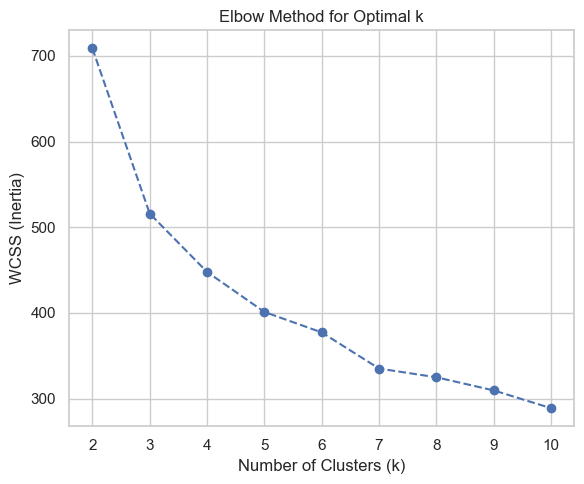

In [100]:
wcss = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.tight_layout()
plt.show()


Applying K-Means


In [101]:
optimal_k = 4
print(f"Applying K-Means with k = {optimal_k}")

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(scaled_features)

df_agg['Cluster'] = cluster_labels

print("\n--- Cluster Assignment Sample ---")
print(df_agg.head())

Applying K-Means with k = 4

--- Cluster Assignment Sample ---
             happiness_score  gdp_per_capita  social_support  life_expectancy  \
country                                                                         
afghanistan          3.51280        0.357113        0.409753         0.254707   
albania              4.71260        0.938633        0.754931         0.787696   
algeria              5.66760        1.012963        1.074205         0.665057   
angola               3.87225        0.798380        0.938368         0.133902   
argentina            6.45940        1.111035        1.330960         0.760895   

              freedom  generosity  corruption  Cluster  
country                                                 
afghanistan  0.117924    0.267730    0.058094        0  
albania      0.371898    0.167887    0.043201        2  
algeria      0.178437    0.069219    0.146099        2  
angola       0.027433    0.105269    0.071570        0  
argentina    0.481620    0.

Creating Clusters

In [102]:
cluster_centroids = df_agg.groupby('Cluster')[cluster_features].mean()

cluster_sizes = df_agg['Cluster'].value_counts().sort_index()
cluster_centroids['ClusterSize'] = cluster_sizes

print("\n--- Cluster Centroids (Average Feature Values per Cluster) ---")
print(cluster_centroids)

cluster_to_show = 0
print(f"\n--- Countries in Cluster {cluster_to_show} ---")
print(df_agg[df_agg['Cluster'] == cluster_to_show].index.tolist())


--- Cluster Centroids (Average Feature Values per Cluster) ---
         happiness_score  gdp_per_capita  social_support  life_expectancy  \
Cluster                                                                     
0               4.186889        0.434920        0.779977         0.329269   
1               6.987800        1.413203        1.344522         0.868612   
2               5.212385        1.014812        1.097101         0.673876   
3               5.991898        1.087289        1.233870         0.714818   

          freedom  generosity  corruption  ClusterSize  
Cluster                                                 
0        0.341125    0.241308    0.117329           51  
1        0.586993    0.332504    0.305786           24  
2        0.304843    0.122741    0.065178           40  
3        0.491315    0.214687    0.100184           46  

--- Countries in Cluster 0 ---
['afghanistan', 'angola', 'bangladesh', 'benin', 'burkina faso', 'burundi', 'cambodia', 'cameroon',

#### Visualizing Clusters using PCA


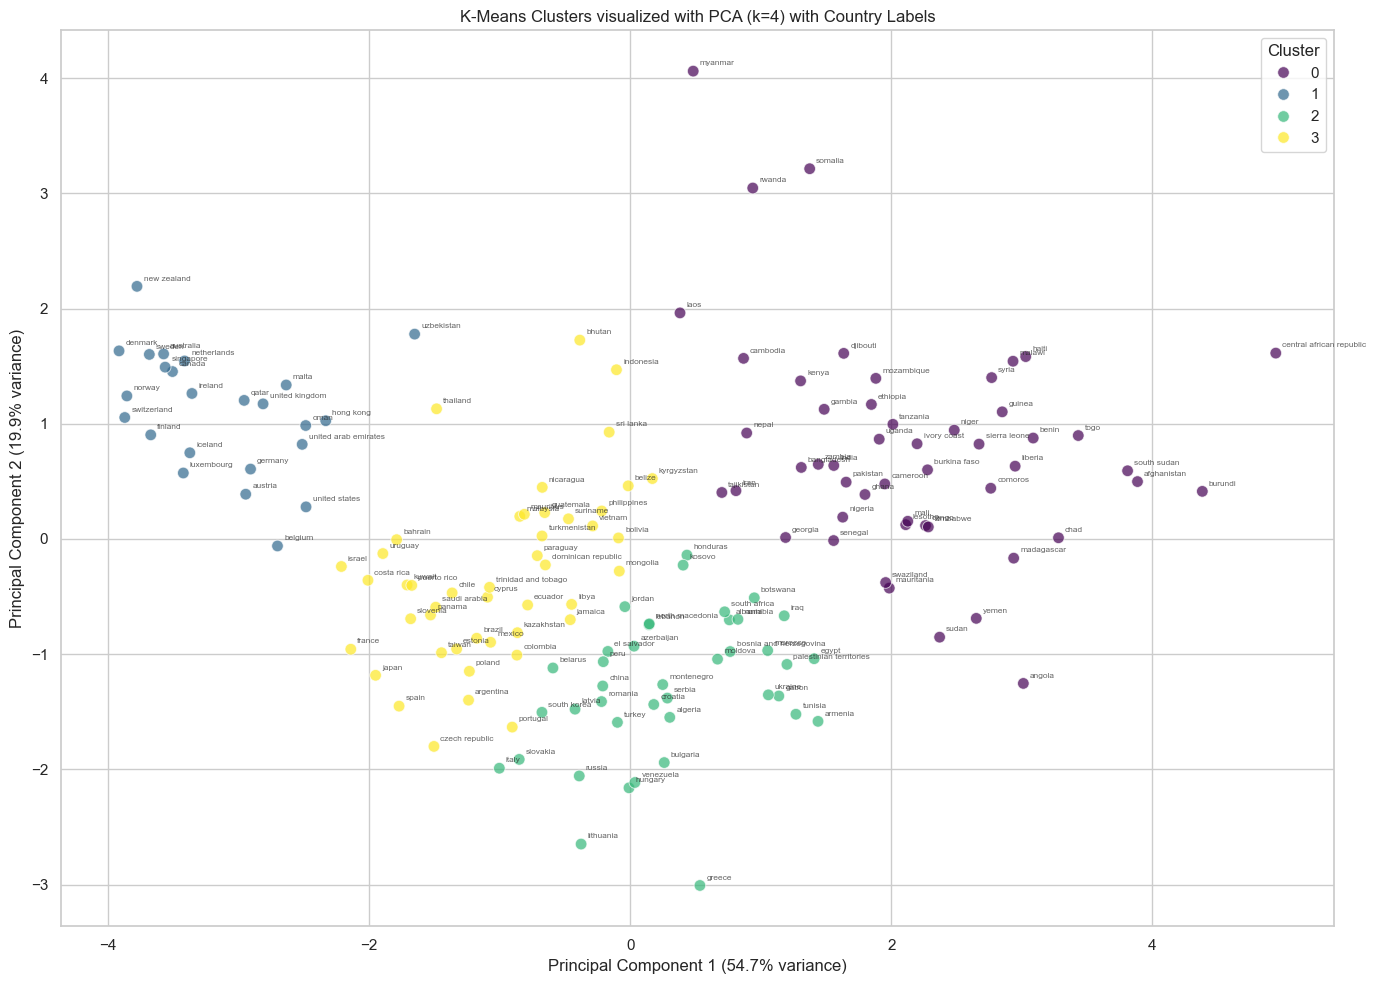

In [103]:
pca = PCA(n_components=2) 
principal_components = pca.fit_transform(scaled_features)

df_pca = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'], index=df_agg.index)
df_pca['Cluster'] = df_agg['Cluster'] 

plt.figure(figsize=(14, 10))
scatter_plot = sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', s=70, alpha=0.7)

for i, country in enumerate(df_pca.index):
    plt.text(df_pca['PC1'][i] + 0.05, 
                df_pca['PC2'][i] + 0.05,
                country,
                fontsize=6,
                alpha=0.7)

plt.title('K-Means Clusters visualized with PCA (k=' + str(optimal_k) + ') with Country Labels')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(title='Cluster')
plt.grid(True)
plt.tight_layout()
plt.show()


# Clustering Analysis

- **Elbow method** indicated optimal *k* = 4, so we created **4 clusters**.

- **PCA Results:**
  - **Principal Component 1** explains **54.7%** of total variance  
  - **Principal Component 2** explains **19.9%** of total variance  
  - **Together**, PC1 + PC2 capture **74.6%** of the dataset’s variance

## Cluster Summaries

| Cluster | Color  | Example Countries                          | Interpretation                                                                                       |
|:-------:|:------:|--------------------------------------------|------------------------------------------------------------------------------------------------------|
| 1       | Blue   | US, UAE, Hong Kong, Germany, UK            | **Developed** high‑income economies: high GDP per capita, excellent healthcare, strong institutions. |
| 2       | Yellow | Colombia, Brazil, Ecuador, Poland, Taiwan  | **Upper‑middle income** / emerging markets: solid social support but higher inequality & volatility. |
| 3       | Green  | Turkey, Algeria, Egypt, Romania, Azerbaijan| **Mid‑tier/transition** economies: moderate GDP, weaker welfare nets, governance challenges.         |
| 4       | Purple | Pakistan, Yemen, Afghanistan, Sudan, Somalia| **Low‑income/developing** or conflict‑affected nations: low GDP, poor health outcomes, weak institutions. |

---

### Limitations & Outliers

Clustering is **not 100% accurate**—countries near cluster boundaries can be misclassified. For example, **Italy**, which logically belongs in Cluster 2 (Yellow), falls into Cluster 3 (Green) because it lies close to the decision boundary in the full feature space. Such outliers remind us that while **PC1+PC2 capture ~75%** (and our full PCA setup retains ~90% of variance), perfect separation isn’t possible. Nevertheless, the majority of countries are well grouped, and the clustering provides a reliable high‑level view of global happiness profiles.


## Q3: Forecasting Future Happiness Scores

We will be training a **Holt’s Linear Trend** model to each country’s historical happiness scores. This model tends to capture both level and trend components, making it well suited for time series with a clear direction. Finally, we will be comparing the rsults with the actual 2020 data.

In [104]:
print("Starting Holt's Linear Trend forecasting for each country...")
forecasts = {}
failed_countries = []

df_sorted = df.sort_values(by=['country', 'year'])

countries = df_sorted['country'].unique()

for country in countries:
    country_data = df_sorted[df_sorted['country'] == country][['year', 'happiness_score']].set_index('year')

    try:
        model = Holt(country_data['happiness_score'], initialization_method='estimated')
        fit = model.fit(optimized=True)

        forecast_value = fit.forecast(steps=1)
        forecasts[country] = forecast_value.iloc[0]

    except:
        pass


forecast_df = pd.DataFrame.from_dict(forecasts, orient='index', columns=['Forecast_2020_Score'])
forecast_df = forecast_df.sort_values(by='Forecast_2020_Score', ascending=False)

print("\n--- Forecasted Happiness Scores for 2020 (Holt's Method - Highly Speculative) ---")
print(forecast_df.head(10))
print("...")
print(forecast_df.tail(10))


Starting Holt's Linear Trend forecasting for each country...

--- Forecasted Happiness Scores for 2020 (Holt's Method - Highly Speculative) ---
             Forecast_2020_Score
finland                 7.906000
denmark                 7.645000
norway                  7.588697
netherlands             7.535000
switzerland             7.473000
iceland                 7.468862
sweden                  7.372000
austria                 7.343257
new zealand             7.322795
luxembourg              7.270000
...
                          Forecast_2020_Score
haiti                                3.366768
zimbabwe                             3.288100
rwanda                               3.260000
lesotho                              3.256992
botswana                             3.208392
malawi                               3.183099
yemen                                3.096640
tanzania                             3.027625
central african republic             2.785293
south sudan                  

Comparing to actual 2020 scores

In [105]:

actual_df = pd.read_csv("2020_actual.csv")

forecast_df_copy = forecast_df.copy()

forecast_df_copy.reset_index(inplace=True)
forecast_df_copy.rename(columns={'index': 'country'}, inplace=True)

comparison_df = pd.merge(forecast_df_copy, actual_df, on='country', how='inner')

comparison_df.rename(columns={'Forecast_2020_Score': 'Predicted_Score', 'score': 'Actual_Score'}, inplace=True)

comparison_df['Absolute_Error'] = abs(comparison_df['Predicted_Score'] - comparison_df['Actual_Score'])
comparison_df['Percentage_Error'] = (comparison_df['Absolute_Error'] / comparison_df['Actual_Score']) * 100

print(comparison_df.head())


mean_absolute_error = comparison_df['Absolute_Error'].mean()
mean_percentage_error = comparison_df['Percentage_Error'].mean()
accuracy = 100 - mean_percentage_error

print(f"\nMean Absolute Error: {mean_absolute_error:.4f}")
print(f"Mean Percentage Error: {mean_percentage_error:.2f}%")
print(f"Accuracy: {accuracy:.2f}%")

       country  Predicted_Score  Actual_Score  Absolute_Error  \
0      finland         7.906000        7.8087        0.097300   
1      denmark         7.645000        7.6456        0.000600   
2       norway         7.588697        7.4880        0.100697   
3  netherlands         7.535000        7.4489        0.086100   
4  switzerland         7.473000        7.5599        0.086900   

   Percentage_Error  
0          1.246045  
1          0.007846  
2          1.344777  
3          1.155872  
4          1.149484  

Mean Absolute Error: 0.1617
Mean Percentage Error: 3.47%
Accuracy: 96.53%


### Analysis

The results from the Holt’s Linear Trend model demonstrate strong predictive performance:

- **Mean Absolute Error (MAE):** 0.1617  
  This indicates that the model’s predicted happiness scores differ from the actual values by only around 0.16 points on average, which is quite low considering the score range is typically between 0 and 10.

- **Mean Percentage Error:** 3.47%  
  The average percentage deviation from the actual scores is under 4%, suggesting that the model captures trends with a high degree of precision.

- **Forecast Accuracy:** 96.53%  
  With an accuracy above 95%, the model proves to be reliable for short-term forecasting of happiness scores.

**Conclusion:**  
Based on these error metrics, Holt’s Linear Trend model offers an acceptable and robust approach for forecasting future happiness scores. While it may not account for sudden shocks or anomalies (e.g., major global events), it performs well when past trends are stable and consistent. The low error values support the model’s suitability for trend-based predictions at a country level.
